In [1]:
import pandas as pd

splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet', 'unsupervised': 'plain_text/unsupervised-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"])
df.iloc[0]

df_fake = pd.read_csv("/kaggle/input/datasets/sametmerts/etiketli/groq_sentetik_10000_ETIKETLI.csv")
df_fake = df_fake.drop(columns=['orijinal'])

In [2]:
import pandas as pd
import torch
import gc
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# ==========================================
# 1. LOAD AND PREP DATA
# ==========================================
# Read your CSV (change paths to your actual files)


# Make sure columns are named correctly for Hugging Face ('text' and 'label')
# Uncomment and adjust this if your columns are named something else like 'review' and 'sentiment':
# df = df.rename(columns={'review': 'text', 'sentiment': 'label'})

# THE FIX: Convert the Pandas DataFrame to a Hugging Face Dataset
hf_dataset = Dataset.from_pandas(df_fake)

# ==========================================
# 2. LOAD MODEL & TOKENIZER
# ==========================================
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# ==========================================
# 3. TOKENIZE DATA
# ==========================================
def tokenize_function(examples):
    return tokenizer(examples["sentetik"], padding="max_length", truncation=True, max_length=256)

# Now we call .map() on the Hugging Face dataset, NOT the Pandas df
tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)
split_dataset = tokenized_datasets.train_test_split(test_size=0.2, seed=42)

# ==========================================
# 4. SET UP TRAINER (T4 Optimized)
# ==========================================
training_args = TrainingArguments(
    output_dir="/kaggle/working/results_roberta", 
    learning_rate=2e-5,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="/kaggle/working/logs_roberta",
    fp16=True,         # Safe to use on the T4 GPU!
    report_to="none"   
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=split_dataset["train"],
    eval_dataset=split_dataset["test"],
)

# ==========================================
# 5. TRAIN & SAVE
# ==========================================
print("Starting training...")
trainer.train()

# Save the final model weights and tokenizer to your working directory
trainer.save_model("/kaggle/working/roberta-finetuned-final")
tokenizer.save_pretrained("/kaggle/working/roberta-finetuned-final")
print("Training complete and model saved!")

# Clean up VRAM
del model, trainer
torch.cuda.empty_cache()
gc.collect()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete and model saved!


1352

Loading fine-tuned model to GPU...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Generating predictions... (This might take a minute)

MODEL EVALUATION SCORES
              precision    recall  f1-score   support

Negative (0)       0.91      0.94      0.93     12500
Positive (1)       0.94      0.91      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



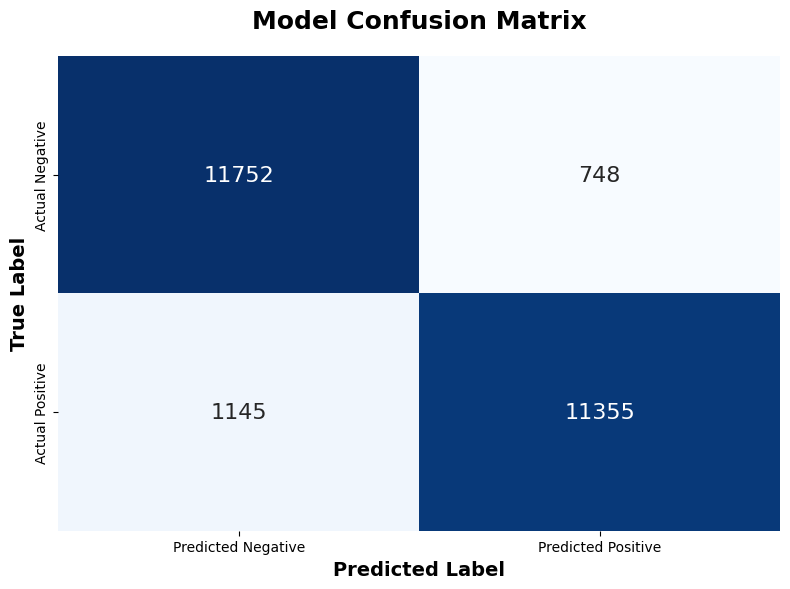

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import pipeline

# ==========================================
# 1. LOAD YOUR TEST DATA
# ==========================================
# If you want to test the model on the data it WASN'T trained on (The Cross-Evaluation Test)
# load the opposite file here! (e.g., if trained on Synthetic, load Real here).
test_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["test"])

# Ensure columns are 'text' and 'label'
# test_df = test_df.rename(columns={'review': 'text', 'sentiment': 'label'})

# To keep the evaluation fast, let's take a random sample of 1,000 reviews. 
# You can remove the .sample() if you want to test the entire dataset.

# ==========================================
# 2. LOAD YOUR FINE-TUNED MODEL
# ==========================================
print("Loading fine-tuned model to GPU...")
model_path = "/kaggle/working/roberta-finetuned-final"

# We use pipeline for fast inference. device=0 forces it to use the T4 GPU.
classifier = pipeline("text-classification", model=model_path, tokenizer=model_path, device=0, truncation=True, max_length=256)

# ==========================================
# 3. GET PREDICTIONS
# ==========================================
print("Generating predictions... (This might take a minute)")
texts = test_df['text'].tolist()
true_labels = test_df['label'].tolist()

# The model outputs labels like 'LABEL_0' or 'LABEL_1'. We need to convert those back to integers (0 or 1)
raw_predictions = classifier(texts, batch_size=16)
predicted_labels = [int(pred['label'].split('_')[-1]) for pred in raw_predictions]

# ==========================================
# 4. CALCULATE SCORES
# ==========================================
print("\n" + "="*50)
print("MODEL EVALUATION SCORES")
print("="*50)

# The classification report gives you Precision, Recall, and F1-Score all at once
report = classification_report(true_labels, predicted_labels, target_names=["Negative (0)", "Positive (1)"])
print(report)

# ==========================================
# 5. PLOT THE CONFUSION MATRIX
# ==========================================
# This creates a beautiful, slide-ready heatmap
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"],
            annot_kws={"size": 16}) # Makes the numbers large enough to read on a projector

plt.title('Model Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save the plot as a high-res image so you can easily drop it into your slides
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300)
plt.show()

In [6]:
!python3 --version

Python 3.12.12
